# Dense Sinkhorn marginal scaling

This notebook generates `fig:sinkhorn-continuous-marginal-scaling`.  Sinkhorn's algorithm alternates the two projections
$$
P\leftarrow \operatorname{diag}\!\left(\frac{a}{P\mathbf 1}\right)P,
\qquad
P\leftarrow P\operatorname{diag}\!\left(\frac{b}{P^\top\mathbf 1}\right),
$$
so each half-step exactly matches one marginal and perturbs the other.  The figure uses a dense one-dimensional Gaussian-mixture problem to show the same mechanism as a smooth matrix scaling process.

In [1]:

from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
import ot

from figure_style import BLUE, RED, VIOLET, GRAY, LIGHT_GRAY, ORANGE, box_axes, coupling_box, figure_dir, remove_axes, save_pdf, setup_matplotlib

setup_matplotlib()
np.random.seed(0)

def normal_pdf(x, mean, std):
    return np.exp(-0.5 * ((x - mean) / std) ** 2) / (std * np.sqrt(2 * np.pi))


def mixture_pdf(x, weights, means, stds):
    out = np.zeros_like(x, dtype=float)
    for w, m, s in zip(weights, means, stds):
        out += w * normal_pdf(x, m, s)
    return out


def sinkhorn_histograms(n=90):
    grid = np.linspace(-3.25, 3.15, n)
    alpha_density = mixture_pdf(grid, [0.58, 0.42], [-1.95, -0.10], [0.34, 0.54])
    beta_density = mixture_pdf(grid, [0.42, 0.58], [-0.75, 1.55], [0.42, 0.36])
    a = alpha_density / alpha_density.sum()
    b = beta_density / beta_density.sum()
    C = (grid[:, None] - grid[None, :]) ** 2
    C = C / np.median(C[C > 0])
    return grid, alpha_density, beta_density, a, b, C


def scaling_states(K, a, b, n_full=40):
    P = K / K.sum()
    out = [('initial', P.copy())]
    for k in range(1, n_full + 1):
        P = (a / np.maximum(P.sum(axis=1), 1e-300))[:, None] * P
        out.append((f'row-{k}', P.copy()))
        P = P * (b / np.maximum(P.sum(axis=0), 1e-300))[None, :]
        out.append((f'column-{k}', P.copy()))
    return out


def sinkhorn_error_curves(a, b, C, epsilons, n_iter=130):
    curves = []
    for eps in epsilons:
        K = np.exp(-C / eps)
        P = K / K.sum()
        errs = [0.5 * (np.abs(P.sum(axis=1)-a).sum() + np.abs(P.sum(axis=0)-b).sum())]
        for _ in range(n_iter):
            P = (a / np.maximum(P.sum(axis=1), 1e-300))[:, None] * P
            errs.append(0.5 * (np.abs(P.sum(axis=1)-a).sum() + np.abs(P.sum(axis=0)-b).sum()))
            P = P * (b / np.maximum(P.sum(axis=0), 1e-300))[None, :]
            errs.append(0.5 * (np.abs(P.sum(axis=1)-a).sum() + np.abs(P.sum(axis=0)-b).sum()))
        curves.append((eps, np.asarray(errs)))
    return curves


def matrix_with_marginal_curves(P, a, b, path, *, gamma=0.45, show_current=True, compact=False, vmax=None):
    n, m = P.shape
    fig, ax = plt.subplots(figsize=(2.18, 2.04) if not compact else (2.05, 1.95))
    scale = max(float(P.max() if vmax is None else vmax), 1e-15)
    image = np.clip(P / scale, 0, 1)
    ax.imshow(image ** gamma, cmap='Greys', origin='lower', extent=(-0.5, m-0.5, -0.5, n-0.5), interpolation='nearest', vmin=0, vmax=1, aspect='auto')

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_frame_on(False)
    coupling_box(ax, n, m, linewidth=0.58)

    row = P.sum(axis=1)
    col = P.sum(axis=0)
    left_base = -0.5 - 0.026 * m
    top_base = n - 0.5 + 0.026 * n
    left_scale = 0.13 * m / max(a.max(), row.max(), 1e-15)
    top_scale = 0.13 * n / max(b.max(), col.max(), 1e-15)
    yy = np.arange(n)
    xx = np.arange(m)

    ax.plot(left_base - left_scale * a, yy, color=RED, lw=0.95, zorder=4)
    ax.fill_betweenx(yy, left_base, left_base - left_scale * a, color=RED, alpha=0.12, linewidth=0, zorder=3)
    ax.plot(xx, top_base + top_scale * b, color=BLUE, lw=0.95, zorder=4)
    ax.fill_between(xx, top_base, top_base + top_scale * b, color=BLUE, alpha=0.12, linewidth=0, zorder=3)

    if show_current:
        ax.plot(left_base - left_scale * row, yy, color=VIOLET, lw=0.80, alpha=0.90, zorder=5)
        ax.fill_betweenx(yy, left_base, left_base - left_scale * row, color=VIOLET, alpha=0.12, linewidth=0, zorder=4)
        ax.plot(xx, top_base + top_scale * col, color=VIOLET, lw=0.80, alpha=0.90, zorder=5)
        ax.fill_between(xx, top_base, top_base + top_scale * col, color=VIOLET, alpha=0.12, linewidth=0, zorder=4)

    ax.set_xlim(-0.5 - 0.18 * m, m - 0.5)
    ax.set_ylim(-0.5, n - 0.5 + 0.18 * n)
    ax.set_xticks([])
    ax.set_yticks([])
    save_pdf(fig, path, pad_inches=0.04)
    plt.close(fig)

fig_name = "sinkhorn-continuous-marginal-scaling"
out = figure_dir(fig_name)


## Dense marginals and selected half-steps

The red and blue side curves are the prescribed histograms.  Violet side curves show the current marginals of the displayed matrix.  A row normalization aligns the red side; a column normalization aligns the blue side.

In [2]:

grid, alpha_density, beta_density, a, b, C = sinkhorn_histograms(n=95)
epsilon = 0.050
K = np.exp(-C / epsilon)
states = dict(scaling_states(K, a, b, n_full=12))
selected = [
    ('initial', 'initial.pdf'),
    ('row-1', 'row-1.pdf'),
    ('column-1', 'column-1.pdf'),
    ('column-12', 'column-12.pdf'),
]

for key, filename in selected:
    matrix_with_marginal_curves(states[key], a, b, out / filename, gamma=0.45, show_current=True)


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


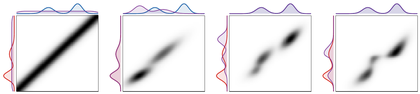

In [3]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/sinkhorn-continuous-marginal-scaling.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/sinkhorn-continuous-marginal-scaling.png")
display(Image(filename=str(_thumb)))
